# ISIC 2024 Skin Cancer Detection
Using pre-trained models from Hugging Face

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
# Install required packages, if working in VScode
#!pip install torch transformers pandas h5py scikit-learn numpy tqdm

In [ ]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [ ]:
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")


In [ ]:
import h5py
from PIL import Image
import io


file_path = r''#file path hdf5

with h5py.File(file_path, 'r') as f:
    key = list(f.keys())[0]
    data = f[key]
    print(f"Key: {key}, Shape: {data.shape}, Dtype: {data.dtype}")
    print(data[...])
    binary_data=f[key][()]
    # Load the image from binary data
    image = Image.open(io.BytesIO(binary_data))  # Decode the binary JPEG
    image = image.convert("RGB")  # Ensure RGB format

    # Print image size for verification
    print(f"Loaded Image Size: {image.size}")




Key: ISIC_0015670, Shape: (), Dtype: |S3325
b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x00\x8b\x00\x8b\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\

Pre-requisite libraries

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'
import h5py
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report
from transformers import AdamW, get_scheduler
from PIL import Image
import io
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import ResNetForImageClassification

## Data Loading and Preprocessing

In [ ]:
class SkinDiseaseDataset(Dataset):
    def __init__(self, hdf5_path, metadata_path, desired_size=224): #changing size 128, 224,256
        self.hdf5_path = hdf5_path

        # Load metadata from CSV
        try:
            self.metadata = pd.read_csv(metadata_path)
        except Exception as e:
            raise ValueError(f"Failed to load metadata from {metadata_path}. Ensure it is a valid CSV file.") from e

        self.desired_size = desired_size

        # Check if required columns exist
        if 'isic_id' not in self.metadata.columns or 'target' not in self.metadata.columns:
            raise ValueError("Metadata file must contain 'isic_id' and 'target' columns.")

        # Define preprocessing transformations
        self.transform = transforms.Compose([
            transforms.Resize((self.desired_size, self.desired_size)),  # Resize to 224x224
            transforms.RandomHorizontalFlip(),  # Random horizontal flip
            transforms.RandomVerticalFlip(),  # Random vertical flip
            transforms.RandomRotation(degrees=15), # Random Rotation
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Random Color Jitter
            transforms.GaussianBlur(kernel_size=(5, 5)), #Gaussian Blur
            transforms.ToTensor(),  # Convert to tensor
            transforms.Normalize(mean=[0.485, 0.455, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize 0.5
        ])

        # Create label encoder for target
        self.unique_diagnoses = self.metadata['target'].unique()
        self.label_to_idx = {label: idx for idx, label in enumerate(self.unique_diagnoses)}

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
      try:
          # Get isic ID and label for this index
          image_id = self.metadata.iloc[idx]['isic_id']
          label = self.metadata.iloc[idx]['target']

          # Open the HDF5 file and read binary data for the image ID
          with h5py.File(self.hdf5_path, 'r') as f:
            if image_id not in f:
              print(f"Image ID {image_id} not found in HDF5 file.")
              return None, None  # Return None immediately if image_id not found

            binary_data = f[image_id][()]

          # Decode the binary JPEG and apply preprocessing
          image = Image.open(io.BytesIO(binary_data)).convert("RGB")  # Convert to RGB
          image = self.transform(image) if self.transform else image

          # Convert label to index
          label_idx = self.label_to_idx[label]


          if image is None or label_idx is None:  # Check if either is None
             # Handle the missing data (e.g., skip, use default values)
                print(f"Warning: Missing data for index {idx}, image_id: {image_id}")
                return torch.zeros(3, self.desired_size, self.desired_size), -1  # Example: Return default values


          return image, label_idx


      except Exception as e:
          print(f"Error loading image with ID  {image_id}: {e}")
          # Handle the exception (e.g., skip, raise an exception)
          print(f"Warning: Skipping index {idx} due to error.")
          return torch.zeros(3, self.desired_size, self.desired_size), -1  # Example: Return default values

testdataset

In [ ]:
class SkinDiseaseTestDataset(Dataset):
    def __init__(self, hdf5_path, metadata_path, desired_size=128):
        self.hdf5_path = hdf5_path

        # Load metadata from CSV
        try:
            self.metadata = pd.read_csv(metadata_path)
        except Exception as e:
            raise ValueError(f"Failed to load metadata from {metadata_path}. Ensure it is a valid CSV file.") from e

        self.desired_size = desired_size

        # Check if required columns exist
        if 'isic_id' not in self.metadata.columns:
            raise ValueError("Metadata file must contain 'isic_id' columns.")

        # Define preprocessing transformations
        self.transform = transforms.Compose([
            transforms.Resize((self.desired_size, self.desired_size)),  # Resize to 224x224
            transforms.ToTensor(),  # Convert to tensor
            transforms.Normalize(mean=[0.485, 0.455, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize
        ])

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
      try:
          # Get isic ID and label for this index
          image_id = self.metadata.iloc[idx]['isic_id']

          # Open the HDF5 file and read binary data for the image ID
          with h5py.File(self.hdf5_path, 'r') as f:
            if image_id not in f:
              print(f"Image ID {image_id} not found in HDF5 file.")
              return None, None  # Return None immediately if image_id not found

            binary_data = f[image_id][()]

          # Decode the binary JPEG and apply preprocessing
          image = Image.open(io.BytesIO(binary_data)).convert("RGB")  # Convert to RGB
          image = self.transform(image) if self.transform else image

          # # Convert label to index
          label_idx = self.label_to_idx[label]


          if image is None:  # Check if either is None
             # Handle the missing data (e.g., skip, use default values)
                print(f"Warning: Missing data for index {idx}, image_id: {image_id}")
                return torch.zeros(3, self.desired_size, self.desired_size), -1  # Example: Return default values


          return image,label_idx


      except Exception as e:
          print(f"Error loading image with ID  {image_id}: {e}")
          # Handle the exception (e.g., skip, raise an exception)
          print(f"Warning: Skipping index {idx} due to error.")
          return torch.zeros(3, self.desired_size, self.desired_size), -1  # Example: Return default values

## Model Architecture

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Available GPUs:", torch.cuda.device_count())
print("Current GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print('current GPU ID: ',torch.cuda.current_device())  # Current GPU ID


CUDA available: True
Available GPUs: 1
Current GPU: NVIDIA A100-SXM4-40GB
current GPU ID:  0


In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-classification", model="microsoft/resnet-50",device=0)


config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# Load model directly
from transformers import AutoImageProcessor, AutoModelForImageClassification

processor = AutoImageProcessor.from_pretrained("microsoft/resnet-50")
#model = AutoModelForImageClassification.from_pretrained("microsoft/resnet-50")


SkinDiseaseClassifier

In [ ]:
class SkinDiseaseClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(SkinDiseaseClassifier, self).__init__()
        self.pretrained_model = ResNetForImageClassification.from_pretrained("microsoft/resnet-50")

        # Freeze the pretrained layers
        for param in self.pretrained_model.parameters():
            param.requires_grad = True #False to freeze

        # Replace the classifier head
        #num_ftrs = self.pretrained_model.classifier[1].in_features  # Access Linear layer
        #self.pretrained_model.classifier[1] = nn.Linear(num_ftrs, num_classes)
        self.pretrained_model.classifier = nn.Sequential(
            nn.Flatten(),#start_dim=1
            nn.Linear(in_features=2048, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=512, out_features=num_classes)
            )


    def forward(self, x):
     x = self.pretrained_model(x).logits
     return x

## Training Functions

In [ ]:
from torch.amp import autocast, GradScaler

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    scaler = GradScaler()

    progress_bar = tqdm(train_loader, desc='Training')
    # Scheduler

    num_training_steps = len(train_loader) * num_epochs
    #scheduler = get_scheduler("linear", optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)
    #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

    accumulation_steps = 8

    for step,(vectors, labels) in enumerate(progress_bar):
        if vectors is None or labels is None: #skip if data is none
            continue
        vectors, labels = vectors.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
          outputs = model(vectors)
          loss = criterion(outputs, labels.type(torch.LongTensor).to(device))

        scaler.scale(loss).backward()
        if (step + 1) % accumulation_steps == 0:
          scaler.step(optimizer)
          scaler.update()

          scheduler.step(loss.item())

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix({
            'loss': total_loss/len(train_loader),
            'accuracy': 100.*correct/total
        })

    return total_loss/len(train_loader), correct/total

In [ ]:
def validate(model, val_loader, criterion, device, is_test_set=False):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data_item in tqdm(val_loader, desc='Validation'):
            if is_test_set:
                # Modification: Check if data_item is a list and extract the first element (image)
                vectors = data_item[0] if isinstance(data_item, list) else data_item
                if vectors is None:
                  continue  # Skip if vectors is None
                labels = torch.tensor([-1] * vectors.shape[0]).to(device)  # Dummy labels for test set
            else:
                vectors, labels = data_item

            vectors = vectors.to(device) #Move vectors to device after assignment
            outputs = model(vectors)

            if not is_test_set:  # Calculate loss and accuracy only for train/val
                loss = criterion(outputs, labels.type(torch.LongTensor).to(device))
                total_loss += loss.item()

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels.type(torch.LongTensor).to(device)).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            else:  # Get predictions for the test set
                _, predicted = outputs.max(1)
                all_preds.extend(predicted.cpu().numpy())

                auc=roc_auc_score(all_labels,all_probs[:,1])#AUC for binary classification
                print(f"Validation AUC: {auc:.4f}")

    if not is_test_set:
        return total_loss / len(val_loader), correct / total, all_preds, all_labels
    else:
        return 0, 0, all_preds, []  # Dummy values for test set

## Main Training Loop

In [ ]:
import pandas as pd
hdf5_path = '/content/drive/MyDrive/skin/challenge-data/train-image.hdf5'
train_metadata_path =  '/content/drive/MyDrive/skin/train-metadata.csv'  # Store path as a variable
train_metadata = pd.read_csv(train_metadata_path) # Read the CSV into a DataFrame
#to access the first row,setting idx
idx = 0
with h5py.File(hdf5_path, 'r') as hdf5_file:
  isic_id = train_metadata.iloc[idx]['isic_id']
  for isic_id in hdf5_file.keys():
    image_vector = hdf5_file[isic_id][()]
    if len(image_vector) % np.dtype(np.float32).itemsize != 0:
      print(f"Data size mismatch for ISIC ID: {isic_id}, size: {len(image_vector)}")
      break  # Stop after finding the first mismatch

<ipython-input-13-b339cf82b09a>:4: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  train_metadata = pd.read_csv(train_metadata_path) # Read the CSV into a DataFrame


Data size mismatch for ISIC ID: ISIC_0015670, size: 3325


<ipython-input-14-4994d60d382e>:4: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(train_metadata_path)


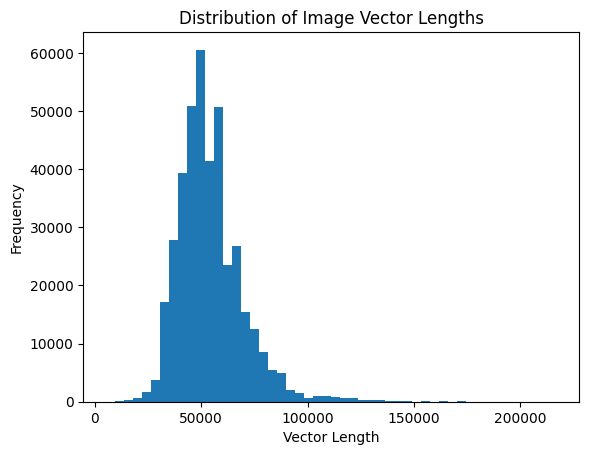

Minimum vector length: 5043
Maximum vector length: 217083
Average vector length: 54264.47115511683
Median vector length: 51483.0


In [ ]:
hdf5_path = ''#train_file_hdf5
train_metadata_path = '' #train_metadata

metadata = pd.read_csv(train_metadata_path)
vector_lengths = []

with h5py.File(hdf5_path, 'r') as hdf5_file:
    for isic_id in metadata['isic_id']:
        if isic_id in hdf5_file:
            image_vector = hdf5_file[isic_id][()]
            if isinstance(image_vector, bytes):  # Ensure data is in bytes
              # Decode the JPEG image from bytes
              image = io.BytesIO(image_vector)
              image = Image.open(image) # Open the image using PIL

              # Convert the image to RGB if it's not already
              image = image.convert('RGB')

              # Get the NumPy array representation of the image
              image_array = np.array(image)

              # Now you can get the vector length from the image array
              vector_lengths.append(len(image_array.flatten()))

# Create histogram
plt.hist(vector_lengths, bins=50)  # Adjust bins as needed
plt.xlabel("Vector Length")
plt.ylabel("Frequency")
plt.title("Distribution of Image Vector Lengths")
plt.show()

# Calculate statistics
print(f"Minimum vector length: {min(vector_lengths)}")
print(f"Maximum vector length: {max(vector_lengths)}")
print(f"Average vector length: {np.mean(vector_lengths)}")
print(f"Median vector length: {np.median(vector_lengths)}")

In [ ]:
from torch.utils.data import DataLoader

# Initialize the dataset
dataset = SkinDiseaseDataset(
    hdf5_path='', # train_image_hdf5
    metadata_path='',  # train metadata path
)

# Create a DataLoader with a small batch size
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

# Check the first batch
for images, labels in train_loader:
    print(f"Image batch shape: {images.shape}")  # Should be (batch_size, 3, 224, 224)
    print(f"Labels: {labels}")
    break


<ipython-input-5-42c6781cc36a>:10: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(metadata_path)


Image batch shape: torch.Size([2, 3, 224, 224])
Labels: tensor([0, 0])


In [ ]:
#this is different way....1
image, label = dataset[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")


Image shape: torch.Size([3, 224, 224])
Label: 0


In [ ]:
#this is different way....2
for images, labels in train_loader:
    print(f"Images shape: {images.shape}")
    print(f"Labels: {labels}")
    break


Images shape: torch.Size([2, 3, 224, 224])
Labels: tensor([0, 0])


In [ ]:
#this is different way....3
progress_bar = tqdm(train_loader, desc="Training")
for step, (vectors, labels) in enumerate(progress_bar):
    print(f"Step {step}: Vectors shape: {vectors.shape}, Labels: {labels}")
    break


Training:   0%|          | 0/200530 [00:00<?, ?it/s]

Step 0: Vectors shape: torch.Size([2, 3, 224, 224]), Labels: tensor([0, 0])


In [ ]:
# Initialize model
model = SkinDiseaseClassifier(num_classes=2) # This creates the SkinDiseaseClassifier with the 'pretrained_model' attribute
model = model.to(device=0) # Move to device
...
#model = ResNetForImageClassification.from_pretrained("microsoft/resnet-50") # This overwrites 'model'

print(model)

SkinDiseaseClassifier(
  (pretrained_model): ResNetForImageClassification(
    (resnet): ResNetModel(
      (embedder): ResNetEmbeddings(
        (embedder): ResNetConvLayer(
          (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (activation): ReLU()
        )
        (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      )
      (encoder): ResNetEncoder(
        (stages): ModuleList(
          (0): ResNetStage(
            (layers): Sequential(
              (0): ResNetBottleNeckLayer(
                (shortcut): ResNetShortCut(
                  (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                  (normalization): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                )
                (layer): Sequentia

In [ ]:
import psutil
print(f"Available Memory: {psutil.virtual_memory().available / (1024 ** 3):.2f} GB")

Available Memory: 78.48 GB


In [ ]:
# Load the CSV file
metadata_path = ''#train_metadata
df = pd.read_csv(metadata_path)

# Check class distribution
class_distribution = df['target'].value_counts()  # Replace 'target_column' with the name of your column
print(class_distribution)


<ipython-input-21-013d2af9d141>:3: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_path)


target
0    400666
1       393
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "None")
print(f"Using device: {device}")

# Load dataset
dataset = SkinDiseaseDataset(
    hdf5_path = ''#TRAIN image,
    metadata_path = '', #metadata train

    desired_size=128
)

# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#Random-Over Sampling

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(np.array(train_dataset.indices).reshape(-1, 1), train_dataset.dataset.metadata['target'][train_dataset.indices])

# Update train_dataset with resampled indices:
train_dataset.indices = X_resampled.flatten()

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,#16
    shuffle=False,
    num_workers=2
)

# Initialize model
model = SkinDiseaseClassifier(num_classes=2)#dataset.get_num_classes()
model = model.to(device)
print(model)

# Initialize loss and optimizer
#class distribution
class_counts = torch.tensor([400666,393])
total_samples = class_counts.sum()
class_weights = total_samples / class_counts
class_weight_1 = class_weights[0].item()
class_weight_2 = class_weights[1].item()

# class_weights = torch.tensor([class_weight_1, class_weight_2]).to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights)

class_weights = torch.tensor([0.5, 1.5]).to(device)  # Adjust based on class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights)

#criterion = nn.CrossEntropyLoss()
#optimizer = optim.AdamW(model.parameters(), lr=5e-5) #3e-5

optimizer = torch.optim.SGD(model.parameters(), lr=3e-5, momentum=0.5)#0.9

# Training loop
num_epochs = 20 #16,32,64
patience=5 #early stopping patience
best_val_acc = 0



for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f"Training Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

    # Validate
    val_loss, val_acc, all_preds, all_labels = validate(model, val_loader, criterion, device)
    print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc*100:.2f}%")

    # Print classification report
    print("\nClassification Report:")
    target_names = [str(name) for name in dataset.unique_diagnoses]
    print(classification_report(all_labels, all_preds, target_names=target_names,zero_division=1))

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print("Saved best model!")



Using device: cuda


<ipython-input-5-42c6781cc36a>:10: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(metadata_path)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


SkinDiseaseClassifier(
  (pretrained_model): ResNetForImageClassification(
    (resnet): ResNetModel(
      (embedder): ResNetEmbeddings(
        (embedder): ResNetConvLayer(
          (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (activation): ReLU()
        )
        (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      )
      (encoder): ResNetEncoder(
        (stages): ModuleList(
          (0): ResNetStage(
            (layers): Sequential(
              (0): ResNetBottleNeckLayer(
                (shortcut): ResNetShortCut(
                  (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                  (normalization): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                )
                (layer): Sequentia

Training:   0%|          | 0/20034 [00:00<?, ?it/s]

Training Loss: 0.6906, Accuracy: 50.47%


Validation:   0%|          | 0/2507 [00:00<?, ?it/s]

Validation Loss: 0.6960, Accuracy: 41.98%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.42      0.59     80134
           1       0.00      0.58      0.00        78

    accuracy                           0.42     80212
   macro avg       0.50      0.50      0.30     80212
weighted avg       1.00      0.42      0.59     80212

Saved best model!

Epoch 2/20


Training:   0%|          | 0/20034 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Test Set Evaluation

In [ ]:
# Load test dataset
test_dataset = SkinDiseaseTestDataset(
    hdf5_path='',  # test data path
    metadata_path=''  #test matadata path as needed
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)
# Load best model
model.load_state_dict(torch.load('best_model.pth', map_location=device, weights_only=True))

# # Evaluate on test set
# test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion, device)
# print(f"\nTest Results:")
# print(f"Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")
# print("\nClassification Report:")
# print(classification_report(test_labels, test_preds, target_names=test_dataset.unique_diagnoses))
# Evaluate on test set

test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion, device, is_test_set=True)
print(f"\nTest Results:")
print("\nPredictions:")
print(test_preds)
print(f"Number of predictions: {len(test_preds)}")

# Create submission DataFrame
submission_df = pd.DataFrame({'isic_id': test_dataset.metadata['isic_id'], 'target': test_preds})

# Save to CSV
submission_df.to_csv('/skin/challenge-data/submission.csv', index=False)

print("Submission file saved to: /skin/challenge-data/submission.csv")

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {correct / total:.2f}")